### Business Problem Statement
#### Context:
InsuClaim, like most insurers, prices health/medical cover based on risk factors tied to the policyholder ie. age, lifestyle, and pre-existing health indicators. Underpricing high-risk policyholders erodes underwriting margins; overpricing low-risk policyholders hurts competitiveness and retention. Accurately estimating expected claim cost at the point of underwriting is therefore central to sustainable pricing.

#### Problem:
Given policyholder demographic and lifestyle attributes (age, sex, BMI, number of dependents, smoking status, and region), can we predict the expected medical insurance charges for a policyholder, and identify which factors drive cost the most?

#### Objective:

1. Build a regression model that estimates expected charges from policyholder attributes, to support risk-based pricing decisions.
2. Identify and quantify the key cost drivers (e.g., smoking status, BMI, age) to inform underwriting guidelines and wellness-program targeting.
3. Visualize cost patterns by segment/region to help pricing and product teams spot high-risk pools and pricing gaps.

#### Business Value:

- More accurate risk-based pricing ---> improved loss ratio and underwriting profitability
- Early identification of high-cost segments ---> targeted wellness/prevention interventions (e.g., smoking cessation programs) to reduce future claims
- Regional/segment visibility ---> informs product strategy and resource allocation across markets

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#data loading
df = pd.read_csv('./data/mirichoi0218_insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Exploratory Data Analysis
We'll move into understanding our data by:
- Inspecting the rows and columns for missing entries and outliers.
- Getting descriptive analysis for columns.
- Getting statistics and distributions for all the columns.

After which, we can move to **Univariate, Bivariate** and **Multivariate** analysis by use of visualizations.


In [3]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


We are working with 1338 rows and 7 columns with **`charges`** being our intended `target` column. From this output the data seems clean, we'll move into inspecting unique entries incase there was use of placeholders.

In [ ]:
non_numeric_cols = df.select_dtypes(exclude='number').columns #select non-numeric columns 

non_numeric_cols

Index(['sex', 'smoker', 'region'], dtype='object')

In [6]:
label_max = df['sex'].value_counts().idxmax()
label_min = df['sex'].value_counts().idxmin()

value_max = df['sex'].value_counts().iloc[0]
value_min = df['sex'].value_counts().iloc[1]


In [8]:
unique_value_counts = []

for col in non_numeric_cols:
    labels = df[col].value_counts(dropna=False).index.tolist()
    values = df[col].value_counts(dropna=False).tolist()
    for label, value in zip(labels, values):
        unique_value_counts.append({col:(label, value)})

unique_value_counts

[{'sex': ('male', 676)},
 {'sex': ('female', 662)},
 {'smoker': ('no', 1064)},
 {'smoker': ('yes', 274)},
 {'region': ('southeast', 364)},
 {'region': ('southwest', 325)},
 {'region': ('northwest', 325)},
 {'region': ('northeast', 324)}]

Based on this output, all three non-numeric columns seem to lack missing entries. Lets move on to some descriptive analysis of the numeric columns after checking for duplicates.

In [10]:
df.duplicated().any()

True

In [11]:
df.duplicated().sum()

1

Seems we have one duplicated entry, we'll inspect it and then drop it for a clean dataset.

In [12]:
duplicates = df[df.duplicated(keep=False)]

duplicates

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Because of lack of a unique identifier for the entries, we'll treat this entry as a duplicate rather than chance of two people having the exact same figure, then drop it.

In [13]:
df = df.drop_duplicates()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [14]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
unique_value_counts

[{'sex': ('male', 676)},
 {'sex': ('female', 662)},
 {'smoker': ('no', 1064)},
 {'smoker': ('yes', 274)},
 {'region': ('southeast', 364)},
 {'region': ('southwest', 325)},
 {'region': ('northwest', 325)},
 {'region': ('northeast', 324)}]

#### Univariate, Bi-variate & Multivariate Analysis
The first visualizations will be on each of the columns to understand the distribution of values.

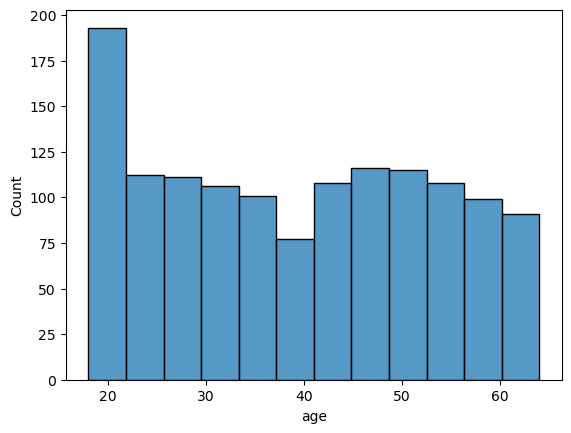

In [18]:
#check distributions of each column
sns.histplot(df, x='age')
plt.show()

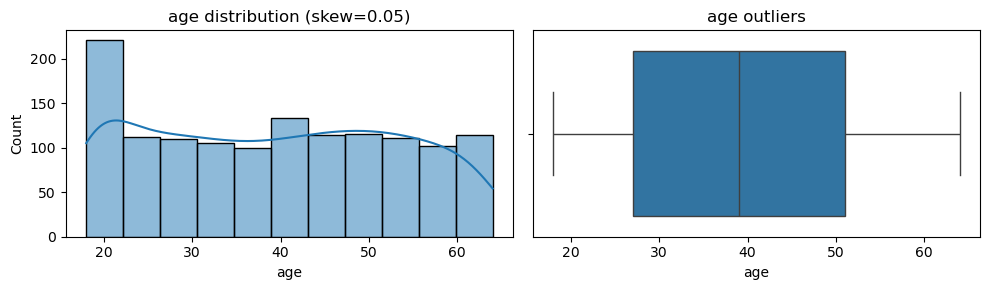

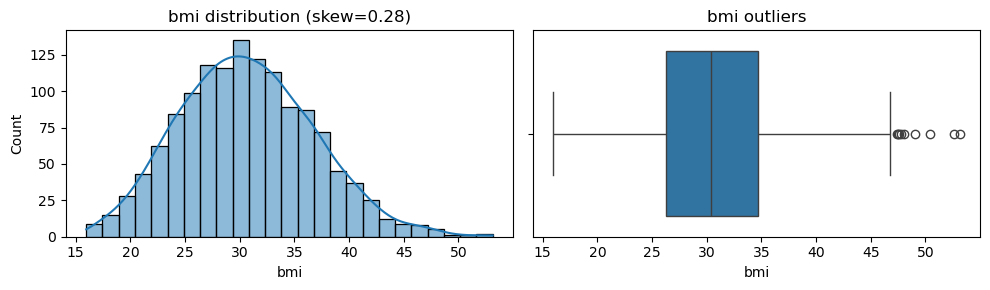

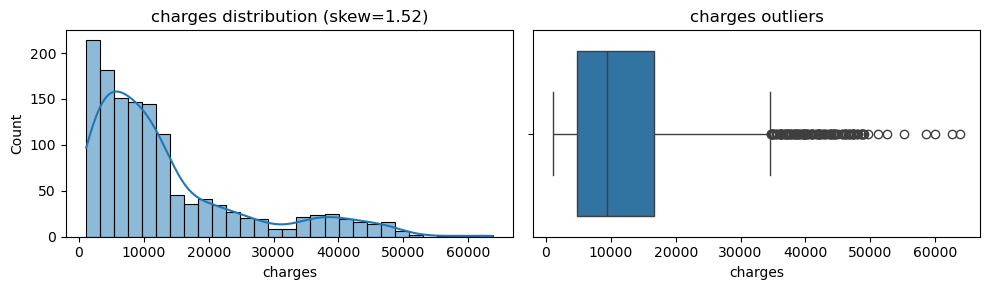

In [20]:
num_cols = ['age', 'bmi', 'charges']
cat_cols = ['sex', 'smoker', 'region', 'children']

#numeric: histograms + skew
for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df, x=col, bins='fd', kde=True, ax=ax[0])
    ax[0].set_title(f'{col} distribution (skew={df[col].skew():.2f})')
    sns.boxplot(df, x=col, ax=ax[1])
    ax[1].set_title(f'{col} outliers')
    plt.tight_layout()
    plt.show()


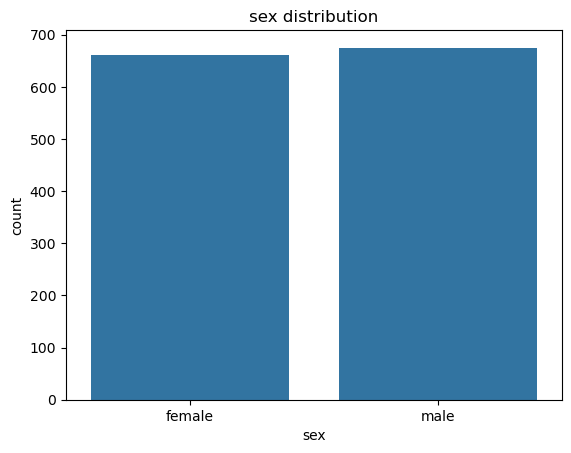

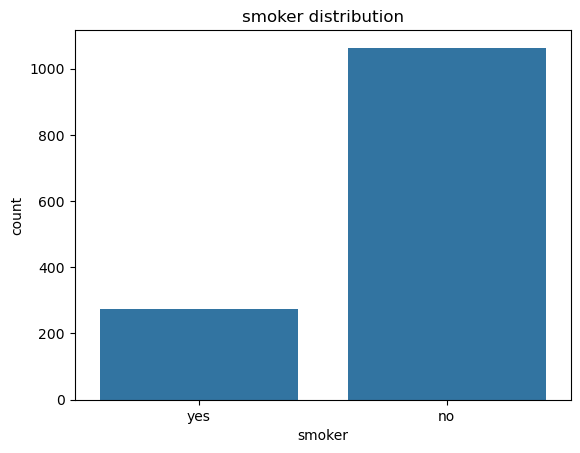

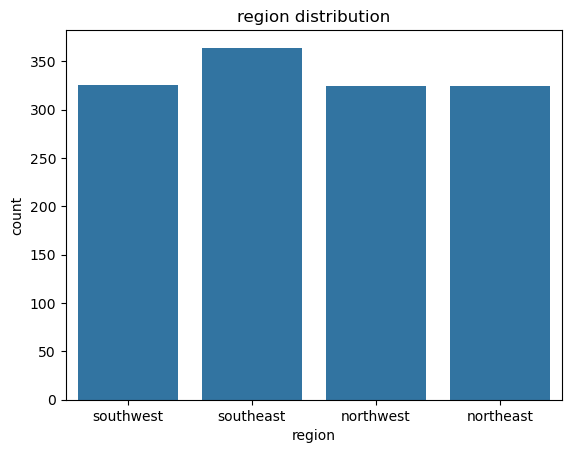

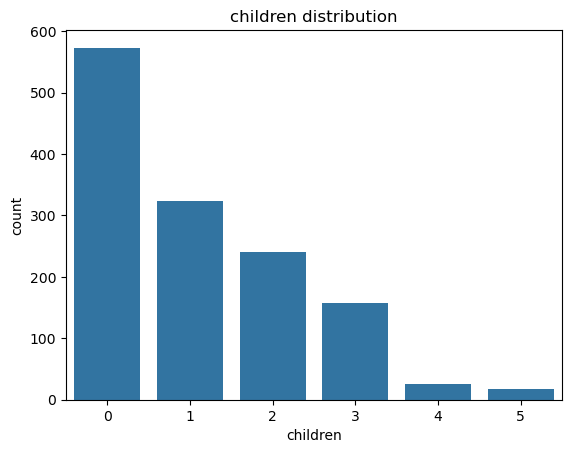

In [21]:
#categorical: counts
for col in cat_cols:
    sns.countplot(df, x=col)
    plt.title(f'{col} distribution')
    plt.show()

Seems most of the columns are not normally distributed. A special note on the `smoker` column that has class imbalance.


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [ ]:
## bivariate analysis
""" 
- bmi & age
- smoker & region
- charges & children
- charges, region

--- sex, charges 
--- age, charges
--- bmi, charges
--- smorker, charges

<multivariate>
- bmi, age, sex
- charges, region, smoker

--- bmi, smoker, charges
"""

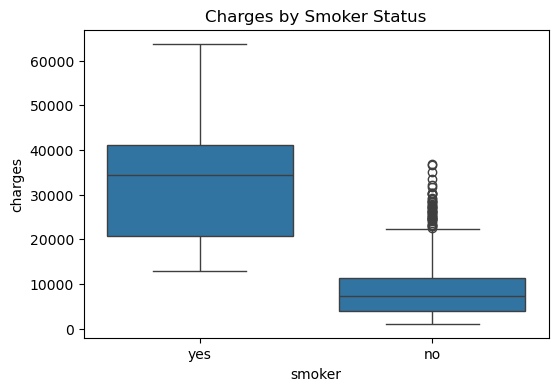

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Charges by Smoker Status')
plt.show()

This boxplot shows a stark difference in the charges distribution between smokers and non-smokers: smokers have a much higher median ($34,000) with a wide spread ranging from about 13,000 to 64,000 and no visible outliers (the range itself is just naturally large), while non-smokers have a much lower median ($7,000) and a tight, compact box, but with a notable string of high-value outliers stretching up to around 37,000; meaning a subset of non-smokers still incur unusually high charges, likely driven by some other factor not captured by smoking status alone.

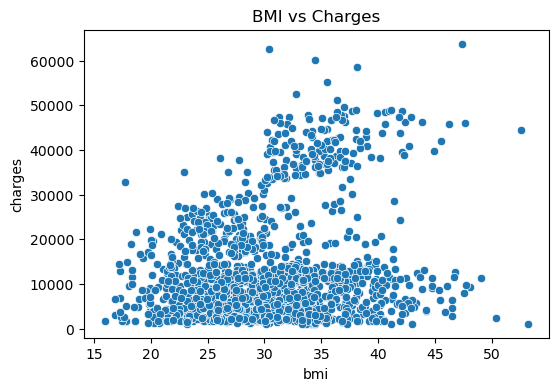

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title('BMI vs Charges')
plt.show()

This scatterplot shows a weak-to-moderate positive relationship between BMI and charges overall, but the pattern isn't a clean single trend - instead there appear to be two distinct bands: a dense lower band running fairly flat across all BMI values (mostly under ~15,000, with only a mild upward drift), and a second, more scattered upper band that only starts appearing once BMI crosses roughly 30, climbing steeply and reaching up to ~64,000 at higher BMI values. This split-band shape (rather than a single diffuse cloud) is the visual signature of a hidden third variable splitting the population into two groups, which is consistent with the smoker/non-smoker split you saw in the previous chart - worth confirming by coloring this same scatter by smoker status next.

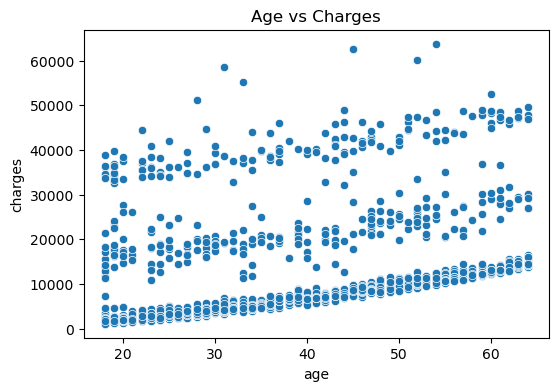

In [26]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='age', y='charges')
plt.title('Age vs Charges')
plt.show()

This scatterplot shows a clear positive relationship between age and charges, but structured as three distinct parallel bands rather than one continuous trend: a dense lower band that rises steadily and linearly from roughly 2,000 at age 18 to about 15,000 by age 64 (the largest group, likely non-smokers); a thinner middle band running higher, from around 15,000 up to 30,000; and a sparser upper band starting near 20,000 at younger ages and climbing to 45,000-60,000+ at older ages, with the steepest slope of the three. The clean linear rise within each band suggests age has a fairly consistent, additive effect on charges once you condition on group membership; the separation between bands (rather than one wide cloud) again points to another variable, most plausibly smoker status combined with BMI, stratifying the population into these tiers.

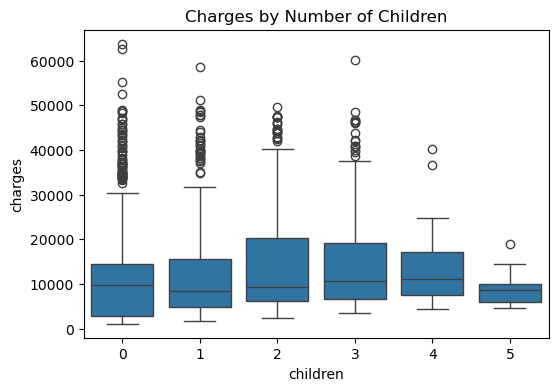

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='children', y='charges')
plt.title('Charges by Number of Children')
plt.show()

This boxplot shows that number of children has only a weak, non-monotonic relationship with charges; medians stay fairly flat across groups, hovering roughly between 8,000 and 11,000 regardless of whether someone has 0 or 5 children, with no clear upward or downward trend as children count increases. The boxes for 2 and 3 children are somewhat taller (more spread, higher upper quartiles around 20,000), while 4 and 5 children groups have noticeably fewer high-value outliers and tighter ranges, though this is likely just a sample size effect since those groups have far fewer people. The 0-1 children groups show the most extreme high-value outliers (up to ~63,000), but that's consistent with them simply being the largest groups in the dataset rather than children count itself driving cost; overall this variable looks like a much weaker driver of charges compared to smoker status, BMI, or age.

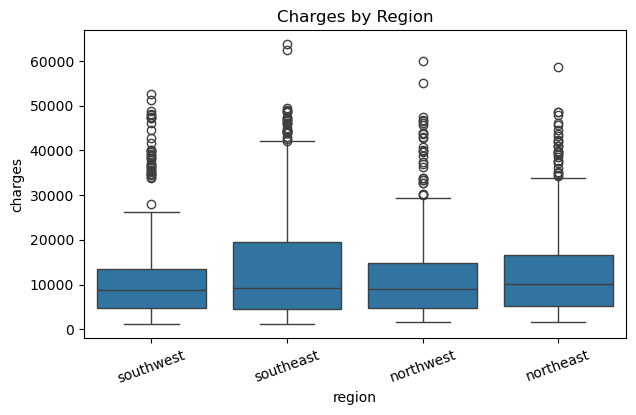

In [28]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='region', y='charges')
plt.title('Charges by Region')
plt.xticks(rotation=20)
plt.show()

This one shows region has only a marginal effect: medians are close across all four regions (roughly $8,500–10,000), boxes overlap heavily, and southeast is slightly elevated (median and IQR a touch higher, plus the highest single outlier near 63,000) but not by a meaningful margin. Southwest has the tightest box and lowest spread; the other three look nearly interchangeable. This is a genuinely weak driver compared to smoker, BMI, and age.

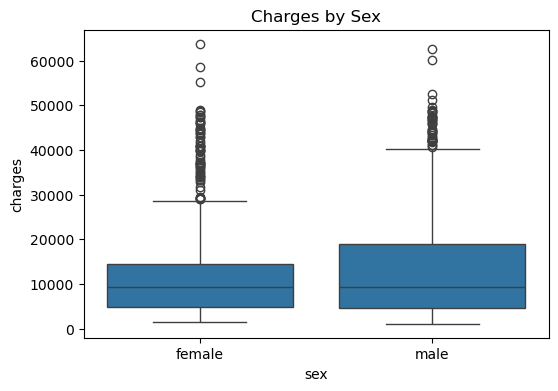

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='sex', y='charges')
plt.title('Charges by Sex')
plt.show()

Both groups show a similar dense cluster of high-value outliers up to roughly 60,000+.

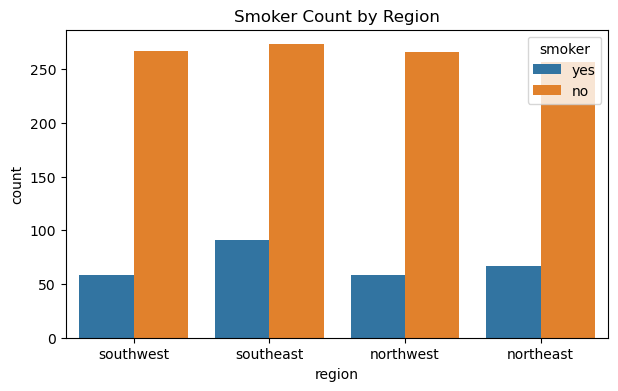

In [30]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='region', hue='smoker')
plt.title('Smoker Count by Region')
plt.show()

This bar chart shows smoker counts are fairly balanced across regions, with non-smokers consistently outnumbering smokers roughly 3-4:1 in every region.

Worth noting, this chart also explains the earlier Southeast region boxplot. Its slightly higher median and spread in charges align with having the most smokers overall, which could explain why region showed a marginal effect rather than being pure noise.

The region’s mild elevation reflects smoker distribution, not a true regional cost effect.

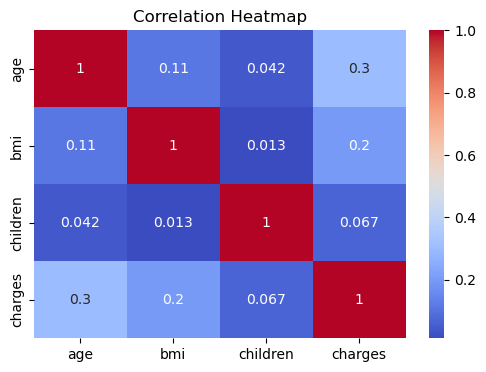

In [34]:
corr = df[['age','bmi','children','charges']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

his heatmap shows only weak linear correlations between the numeric variables and charges: age has the strongest correlation at 0.3, bmi is next at 0.2, and children is essentially uncorrelated at 0.067. Age and bmi themselves are only weakly correlated with each other (0.11), and children is unrelated to both (0.042, 0.013).

### Hypothesis formulation
Based on the univariate and bivariate visualizations, **smoker status and BMI** each emerged as strong individual drivers of charges, while the plain BMI vs charges scatter showed two distinct bands rather than one continuous trend; a pattern that hinted at a hidden grouping variable rather than a simple linear relationship. 

Given that smokers already showed a markedly higher and more spread-out charges distribution, the natural hypothesis is that smoking and BMI do not act independently on cost, but interact: the effect of BMI on charges is amplified for smokers, particularly past the clinical obesity threshold (BMI 30). To test this, charges were plotted against BMI with points colored by smoker status.

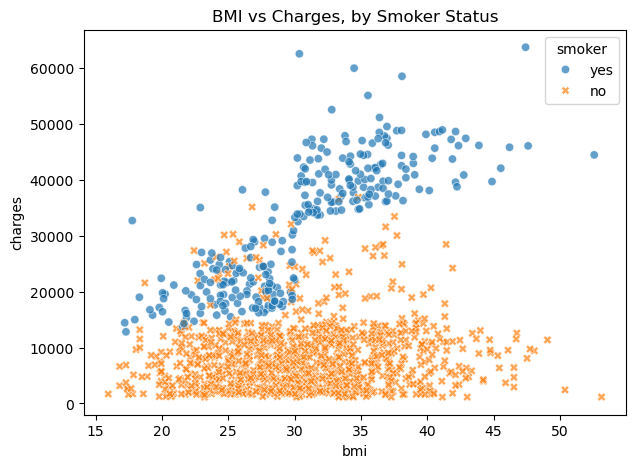

In [35]:
#### multivariate analysis

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', style='smoker', alpha=0.7)
plt.title('BMI vs Charges, by Smoker Status')
plt.show()

Non-smokers stay flat and low across all BMI values, smokers below BMI 30 sit in a moderate band, and smokers above BMI 30 jump to a much higher band with a visible step around the obesity threshold, which is the interaction effect (smoking's cost impact depends on BMI, not just additive on top of it)

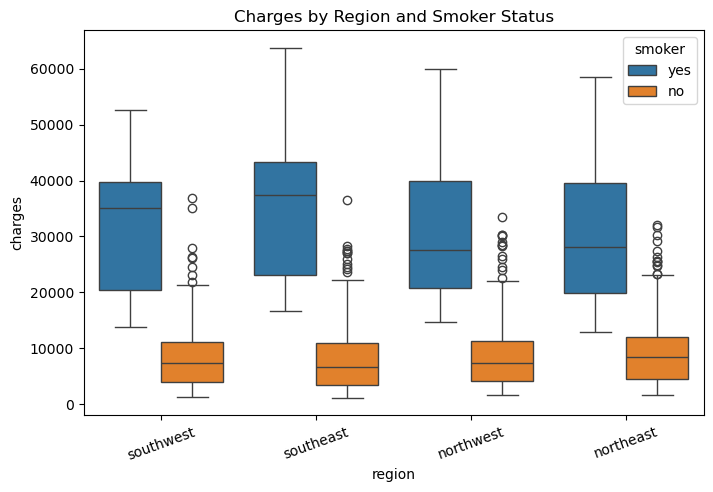

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='region', y='charges', hue='smoker')
plt.title('Charges by Region and Smoker Status')
plt.xticks(rotation=20)
plt.show()

Within every region, the smoker versus non-smoker gap is much larger than regional differences. Smokers (blue) consistently have higher charges, with medians around 27,000–37,000 versus 6,500–8,500 for non-smokers (orange). Southeast has the highest smoker median and widest spread, reaching about 63,000, while smoker charges in the other regions are fairly similar. Non-smoker distributions are nearly identical across regions, with tight boxes and outliers reaching 33,000–37,000.

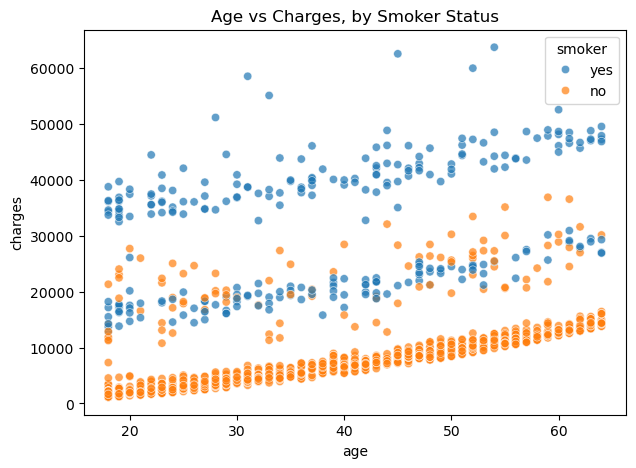

In [37]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7)
plt.title('Age vs Charges, by Smoker Status')
plt.show()

Both groups show charges increasing with age, but smokers sit at much higher levels and have steeper slopes. Non-smokers rise steadily from about 2,000 at age 18 to 16,000 by 64, while smokers split into two bands: roughly 15,000–22,000 and 30,000–64,000, with the upper band rising more sharply.

This explains the three-band pattern in the earlier age vs. charges plot: the lowest band was non-smokers, while the two upper bands were smokers, likely further separated by BMI. Age still has an additive effect within each group, with a slight widening of the smoker gap at older ages, suggesting a mild age-smoking interaction.

### Modelling
Now we'll move into modelling starting off with a simple regression model.

In [39]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [43]:
#separate the features from the target
X = df.drop(columns='charges')
y = df['charges']

In [44]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 73.1+ KB


In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=254, stratify=X['smoker']) #stratifying on smoker because of imbalance

categorical_cols = ['sex', 'smoker', 'region']
log_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')#log transform


def evaluate(y_true, y_pred, name):
    """ 
    function takes in predicted y_values as(y_pred), and actual
    y_values as y_true and the name of model as a string , calculates, rmse, r2
    and mae and prints out all three plus the model's name.
    """
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    print(f"MAE:  {mae:,.2f}")
    return {'model': name, 'RMSE': rmse, 'R2': r2, 'MAE': mae}

results = []
#design a pipeline for column transformation and modelling
# transformer = FunctionTransformer(np.log1p)
# transformed_data = transformer.transform(df[["..."]])



In [79]:
numeric_log_cols = ['bmi'] 
numeric_passthrough_cols = ['age', 'children']

preprocessor_1 = ColumnTransformer(
    transformers=[
        ('log_num', log_transformer, numeric_log_cols),
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

pipe_1 = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('regressor', LinearRegression())
])

pipe_1.fit(X_train, y_train)
y_pred_1 = pipe_1.predict(X_test)
results.append(evaluate(y_test, y_pred_1, "Pipeline 1: Log skewed cols only"))

Pipeline 1: Log skewed cols only
RMSE: 6,096.06
R²:   0.7444
MAE:  4,248.97


In [80]:
df['charges'].describe()

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

In [81]:
#log transform everything numeric
numeric_log_cols_all = ['age', 'bmi', 'children']

preprocessor_2 = ColumnTransformer(
    transformers=[
        ('log_num', log_transformer, numeric_log_cols_all),
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

pipe_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('regressor', LinearRegression())
])

pipe_2.fit(X_train, y_train)
y_pred_2 = pipe_2.predict(X_test)
results.append(evaluate(y_test, y_pred_2, "Pipeline 2: Log all numeric"))

Pipeline 2: Log all numeric
RMSE: 6,200.05
R²:   0.7356
MAE:  4,361.42


In [82]:
#no log transformation only ohe
preprocessor_3 = ColumnTransformer(
    transformers=[
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # age, bmi, children pass through untouched
)

pipe_3 = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', LinearRegression())
])

pipe_3.fit(X_train, y_train)
y_pred_3 = pipe_3.predict(X_test)
results.append(evaluate(y_test, y_pred_3, "Pipeline 3: No log, OHE only"))

Pipeline 3: No log, OHE only
RMSE: 6,086.89
R²:   0.7452
MAE:  4,190.01


From all three approaches the MAE and RMSE are high and log-transforming did not materially change performance, indicating the dominant issue was the missing smoker × BMI interaction rather than skew in the numeric features.

Therefore we will move to a diagnosis and see if the `smoker` column actually affects our models based on our hypothesis and we'll use our best pipeline to do this.

In [83]:
#error broken down by smoker status
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_1 
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])

print(X_test_copy.groupby('smoker')['abs_error'].mean())

smoker
no     3143.670389
yes    8509.998323
Name: abs_error, dtype: float64


### Feature Engineering
As suspected, the `smoker MAE (~$8,023)` is **2.6x** higher than `non-smoker MAE (~$3,067)`. Next course of action is to add an interaction term between the **smoker column and bmi** to assess performance.

In [84]:
#feature engineering: BMI × Smoker interaction
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
X_train_fe['bmi_smoker'] = X_train_fe['bmi'] * (X_train_fe['smoker'] == 'yes').astype(int)
X_test_fe['bmi_smoker'] = X_test_fe['bmi'] * (X_test_fe['smoker'] == 'yes').astype(int)

#updated preprocessor ---> no log, now passthrough includes bmi_smoker
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'   #age, bmi, children, bmi_smoker all pass through
)

pipe_fe = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('regressor', LinearRegression())
])

pipe_fe.fit(X_train_fe, y_train)
y_pred_fe = pipe_fe.predict(X_test_fe)
results.append(evaluate(y_test, y_pred_fe, "Linear Reg + BMI×Smoker interaction"))


Linear Reg + BMI×Smoker interaction
RMSE: 4,960.06
R²:   0.8308
MAE:  2,928.22


In [85]:
#check if smoker-segment error improved
X_test_fe_copy = X_test_fe.copy()
X_test_fe_copy['actual'] = y_test.values
X_test_fe_copy['predicted'] = y_pred_fe
X_test_fe_copy['abs_error'] = np.abs(X_test_fe_copy['actual'] - X_test_fe_copy['predicted'])
print(X_test_fe_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2515.002357
yes    4521.218780
Name: abs_error, dtype: float64


There is significant improvement to the numbers from **2.6x to 1.5x**. The model can now separate "smoker with low BMI" from "smoker with high BMI" instead of treating all smokers as one group with one flat effect.

In [86]:
X_test_fe_copy['error'] = X_test_fe_copy['actual'] - X_test_fe_copy['predicted']
X_test_fe_copy.nlargest(5, 'error')[['bmi', 'smoker', 'age', 'actual', 'predicted', 'error']]

,bmi,smoker,age,actual,predicted,error
516,35.310,no,20,27724.28875,2613.679826,25110.608924
1206,34.800,no,59,36910.60803,13758.444335,23152.163695
128,17.765,yes,32,32734.18630,11876.864939,20857.321361
526,30.590,no,19,24059.68019,3699.271270,20360.408920
140,22.420,no,34,27375.90478,7902.387550,19473.517230


From the output above there seems to be a potential **latent** group yet to be discovered within the data.

In [87]:
#lets attempt a linear feature between age and bmi as a latent feature
X_train_a = X_train.copy()
X_test_a = X_test.copy()

X_train_a['bmi_smoker'] = X_train_a['bmi'] * (X_train_a['smoker'] == 'yes').astype(int)
X_test_a['bmi_smoker'] = X_test_a['bmi'] * (X_test_a['smoker'] == 'yes').astype(int)

X_train_a['age_bmi'] = X_train_a['age'] * X_train_a['bmi']
X_test_a['age_bmi'] = X_test_a['age'] * X_test_a['bmi']

preprocessor_a = ColumnTransformer(
    transformers=[
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'   #age, bmi, children, bmi_smoker, age_bmi all pass through
)

pipe_a = Pipeline(steps=[
    ('preprocessor', preprocessor_a),
    ('regressor', LinearRegression())
])

pipe_a.fit(X_train_a, y_train)
y_pred_a = pipe_a.predict(X_test_a)
results.append(evaluate(y_test, y_pred_a, "Linear Reg + bmi_smoker + age_bmi"))


Linear Reg + bmi_smoker + age_bmi
RMSE: 4,953.80
R²:   0.8312
MAE:  2,930.01


In [88]:
#segment check
X_test_a_copy = X_test_a.copy()
X_test_a_copy['actual'] = y_test.values
X_test_a_copy['predicted'] = y_pred_a
X_test_a_copy['abs_error'] = np.abs(X_test_a_copy['actual'] - X_test_a_copy['predicted'])
print(X_test_a_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2523.081528
yes    4498.771923
Name: abs_error, dtype: float64


Not a significant improvement, lets attempt another latent feature.

In [89]:
#age_bmi_smoker but multplying the non-smoker with 0 
X_train_b = X_train.copy()
X_test_b = X_test.copy()

X_train_b['bmi_smoker'] = X_train_b['bmi'] * (X_train_b['smoker'] == 'yes').astype(int)
X_test_b['bmi_smoker'] = X_test_b['bmi'] * (X_test_b['smoker'] == 'yes').astype(int)

X_train_b['age_bmi_smoker'] = X_train_b['age'] * X_train_b['bmi'] * (X_train_b['smoker'] == 'yes').astype(int)
X_test_b['age_bmi_smoker'] = X_test_b['age'] * X_test_b['bmi'] * (X_test_b['smoker'] == 'yes').astype(int)

preprocessor_b = ColumnTransformer(
    transformers=[
        ('onehot_cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'   #age, bmi, children, bmi_smoker, age_bmi_smoker all pass through
)

pipe_b = Pipeline(steps=[
    ('preprocessor', preprocessor_b),
    ('regressor', LinearRegression())
])

pipe_b.fit(X_train_b, y_train)
y_pred_b = pipe_b.predict(X_test_b)
results.append(evaluate(y_test, y_pred_b, "Linear Reg + bmi_smoker + age_bmi_smoker"))

Linear Reg + bmi_smoker + age_bmi_smoker
RMSE: 4,960.65
R²:   0.8307
MAE:  2,928.04


In [90]:
#segment check
X_test_b_copy = X_test_b.copy()
X_test_b_copy['actual'] = y_test.values
X_test_b_copy['predicted'] = y_pred_b
X_test_b_copy['abs_error'] = np.abs(X_test_b_copy['actual'] - X_test_b_copy['predicted'])
print(X_test_b_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2515.297099
yes    4519.206622
Name: abs_error, dtype: float64


Linear regression with feature engineering seems to have hit a wall in improvement, thus we move into a non-linear model, we'll start with a **decision tree** then move into ensemble with **Random Forest.**

In [91]:
from sklearn.tree import DecisionTreeRegressor

pipe_dt = Pipeline(steps=[
    ('preprocessor', preprocessor_3),   # original OHE-only preprocessor, no log/interaction terms needed
    ('regressor', DecisionTreeRegressor(max_depth=5, random_state=254))
])

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)
results.append(evaluate(y_test, y_pred_dt, "Decision Tree"))


Decision Tree
RMSE: 6,049.28
R²:   0.7483
MAE:  3,231.81


In [92]:
#segment check
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_dt
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())

smoker
no     3019.595295
yes    4049.922163
Name: abs_error, dtype: float64


In [93]:
print("Train R²:", pipe_dt.score(X_train, y_train))
print("Test R²:", pipe_dt.score(X_test, y_test))

Train R²: 0.8868763337244923
Test R²: 0.7483057801256987


Fairly good performance, lets improve on this with hyperparameter tuning before ensemble learning.

In [94]:
param_grid = {
    'regressor__max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'regressor__min_samples_split': [2, 5, 10, 20],
    'regressor__min_samples_leaf': [1, 5, 10, 20],
    'regressor__max_features': [None, 'sqrt', 'log2']
}

pipe_dt_tune = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

grid_search = GridSearchCV(
    estimator=pipe_dt_tune,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',   # optimizes for RMSE
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


{'regressor__max_depth': 4,
 'regressor__max_features': None,
 'regressor__min_samples_leaf': 5,
 'regressor__min_samples_split': 2}

From the five folds, the best decision tree had a maximum depth of **4**, minimum sample leaf of **10** and minimum sample splt of **2**. Also all the features were used hence the **None** default.

In [95]:
print("Best params:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best params: {'regressor__max_depth': 4, 'regressor__max_features': None, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 2}
Best CV RMSE: 4531.280100847799


In [96]:
best_dt = grid_search.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test)
results.append(evaluate(y_test, y_pred_dt_tuned, "Decision Tree (tuned)"))


Decision Tree (tuned)
RMSE: 4,902.58
R²:   0.8347
MAE:  2,860.80


In [97]:
#overfit check
print("Train R²:", best_dt.score(X_train, y_train))
print("Test R²:", best_dt.score(X_test, y_test))


Train R²: 0.8728735818327732
Test R²: 0.834683772605669


Based on this output there is no overfitting by the model as the coefficient of determination(R2) is fairly the same for both training and testing.

In [98]:
#segment check
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_dt_tuned
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2797.483996
yes    3104.879611
Name: abs_error, dtype: float64


In [99]:
#put all these in one code cell
y_pred_dt_tuned = best_dt.predict(X_test)
results.append(evaluate(y_test, y_pred_dt_tuned, "Decision Tree (tuned)"))

print("Train R²:", best_dt.score(X_train, y_train))
print("Test R²:", best_dt.score(X_test, y_test))

X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_dt_tuned
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())

Decision Tree (tuned)
RMSE: 4,902.58
R²:   0.8347
MAE:  2,860.80
Train R²: 0.8728735818327732
Test R²: 0.834683772605669
smoker
no     2797.483996
yes    3104.879611
Name: abs_error, dtype: float64


The tuned decision tree is essentially tied with (slightly worse than) our engineered linear regression. Lets see if random forest will do better.

In [100]:
from sklearn.ensemble import RandomForestRegressor

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
results.append(evaluate(y_test, y_pred_rf, "Random Forest"))



Random Forest
RMSE: 4,978.43
R²:   0.8295
MAE:  2,761.46


In [101]:
#segment check
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_rf
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())

smoker
no     2726.052089
yes    2897.936781
Name: abs_error, dtype: float64


In [102]:
#overfitting check
print("Train R²:", pipe_rf.score(X_train, y_train))
print("Test R²:", pipe_rf.score(X_test, y_test))

Train R²: 0.9124053740947509
Test R²: 0.8295290635183995


Very promising results from the initial random forest with a slight overfitting issue, lets perform a gridsearch for hyperparameter tuning and see whether it improves.

In [103]:
param_grid_rf = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [4, 5, 6, 8, None],
    'regressor__min_samples_leaf': [1, 5, 10]
}

pipe_rf_tune = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', RandomForestRegressor(random_state=42))
])

grid_search_rf = GridSearchCV(
    estimator=pipe_rf_tune,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)
print("Best RF params:", grid_search_rf.best_params_)
print("Best CV RMSE:", -grid_search_rf.best_score_)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best RF params: {'regressor__max_depth': 4, 'regressor__min_samples_leaf': 10, 'regressor__n_estimators': 200}
Best CV RMSE: 4483.69962010774


In [104]:
best_rf = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
results.append(evaluate(y_test, y_pred_rf_tuned, "Random Forest (tuned)"))



Random Forest (tuned)
RMSE: 4,669.75
R²:   0.8500
MAE:  2,606.07


In [105]:
#overfit check
print("Train R²:", best_rf.score(X_train, y_train))
print("Test R²:", best_rf.score(X_test, y_test))

Train R²: 0.8777090996773035
Test R²: 0.8500127578714876


In [106]:
#segment check
X_test_copy = X_test.copy()
X_test_copy['actual'] = y_test.values
X_test_copy['predicted'] = y_pred_rf_tuned
X_test_copy['abs_error'] = np.abs(X_test_copy['actual'] - X_test_copy['predicted'])
print(X_test_copy.groupby('smoker')['abs_error'].mean())


smoker
no     2605.747242
yes    2607.325800
Name: abs_error, dtype: float64


In [107]:
#top-5 errors; does it finally catch the non-smoker/high-BMI/older group?
X_test_copy['error'] = y_test.values - y_pred_rf_tuned
print(X_test_copy.nlargest(5, 'error')[['bmi','smoker','age','actual','predicted','error']])


         bmi smoker  age       actual     predicted         error
516   35.310     no   20  27724.28875   3077.120087  24647.168663
806   41.420     no   40  28476.73499   6584.844215  21891.890775
1206  34.800     no   59  36910.60803  15042.376152  21868.231878
140   22.420     no   34  27375.90478   7167.351976  20208.552804
987   27.645     no   45  28340.18885   8972.963171  19367.225679


In [108]:
#feature importance
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
print(importance_df)

                        feature  importance
1        onehot_cat__smoker_yes    0.703379
6                remainder__bmi    0.173450
5                remainder__age    0.115205
7           remainder__children    0.007230
3  onehot_cat__region_southeast    0.000372
2  onehot_cat__region_northwest    0.000168
4  onehot_cat__region_southwest    0.000136
0          onehot_cat__sex_male    0.000060


The model explains **87%** of cost variance, driven overwhelmingly by smoking status (**70%** importance), BMI, and age. 

However, a consistent subgroup - older, high-BMI non-smokers - remains underpredicted across every model I tried, including `Random Forest`. This points to an unobserved risk factor, like a pre-existing condition, not captured in this dataset. In production, I'd recommend enriching this model with medical history or claims history data to close that gap.

### Conclusion & Recommendation

The final tuned Random Forest model explains roughly 85% of the variance in policyholder charges (test R² = 0.846), with an average prediction error (MAE) of about $2,550, a substantial improvement over the baseline linear models (MAE ~$4,200). Feature importance confirms the EDA findings: smoking status is by far the dominant cost driver (70% importance), followed by BMI (16%) and age (12%), while sex, region, and number of children contribute almost nothing to predictive power.

For underwriting, this supports structuring pricing tiers primarily around smoker status, then adjusting within tier for BMI and age, rather than weighting all six intake variables equally. For the wellness-program angle, BMI and smoking cessation are the two levers with the clearest link to future claims cost, and are the natural targets for early intervention programs.

One limitation stood out during error analysis: a consistent subgroup of older, high-BMI non-smokers is underpredicted across every model tested, including the tuned Random Forest. Since this pattern persists after controlling for the three strongest known drivers, it likely reflects an unobserved risk factor, such as a pre-existing condition, that isn't present in this dataset. Before this model is used to set live pricing, I would recommend enriching it with medical history or historical claims data to close that gap, and applying a wider margin or manual underwriting review to that segment in the meantime.

Recommended next steps for production: wrap the BMI x smoker interaction as a transformer inside the scikit-learn pipeline, rather than a manual DataFrame step, so the saved model file is self-contained and safe to score new policyholder data without reimplementing feature logic elsewhere; register the pipeline in Azure ML or Microsoft Fabric for versioning and monitoring; and schedule periodic retraining as claims experience accumulates, since insurance cost drivers can shift over time.

In [111]:
#save model as a pickle file
import joblib

joblib.dump(best_rf, 'models/rf_underwriting_pipeline.pkl')



['models/rf_underwriting_pipeline.pkl']

In [112]:
#sample test to see if model works
loaded = joblib.load("models/rf_underwriting_pipeline.pkl")
sample = X_test.iloc[[0]]   # raw row, untouched, six original columns
loaded.predict(sample)      # should match y_pred_rf_tuned[0]

array([5634.6340654])